# Proyecto 2 — SmartCity IA
## Módulo 1: Detección de Actividad Sospechosa en CCTV con CNN
**Dataset:** Videos editados | **Arquitectura:** CNN desde cero (TensorFlow/Keras)
**Clases:** Normal · Robo_Asalto · Pelea · Vandalismo

# 1.Importación librerías

In [210]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU disponible: []


# 2.Importación fuente de datos

In [211]:
#Rutas del dataset — frames generados por 01_EDA_editados.ipynb
#train_path = r'C:\Users\victo\Downloads\videos editados\frames\train'
train_path = r'D:\videos editados\frames\train'
#test_path  = r'C:\Users\victo\Downloads\videos editados\frames\test'
test_path  = r'D:\videos editados\frames\test'


print('Clases en train:', os.listdir(train_path))
print('Clases en test :', os.listdir(test_path))

Clases en train: ['Normal', 'Pelea', 'Robo_Asalto', 'Vandalismo']
Clases en test : ['Normal', 'Pelea', 'Robo_Asalto', 'Vandalismo']


In [212]:
os.listdir(train_path)

['Normal', 'Pelea', 'Robo_Asalto', 'Vandalismo']

In [213]:
os.listdir(test_path)

['Normal', 'Pelea', 'Robo_Asalto', 'Vandalismo']

# 3.Preprocesado

## 3.1 Visualización de imágenes

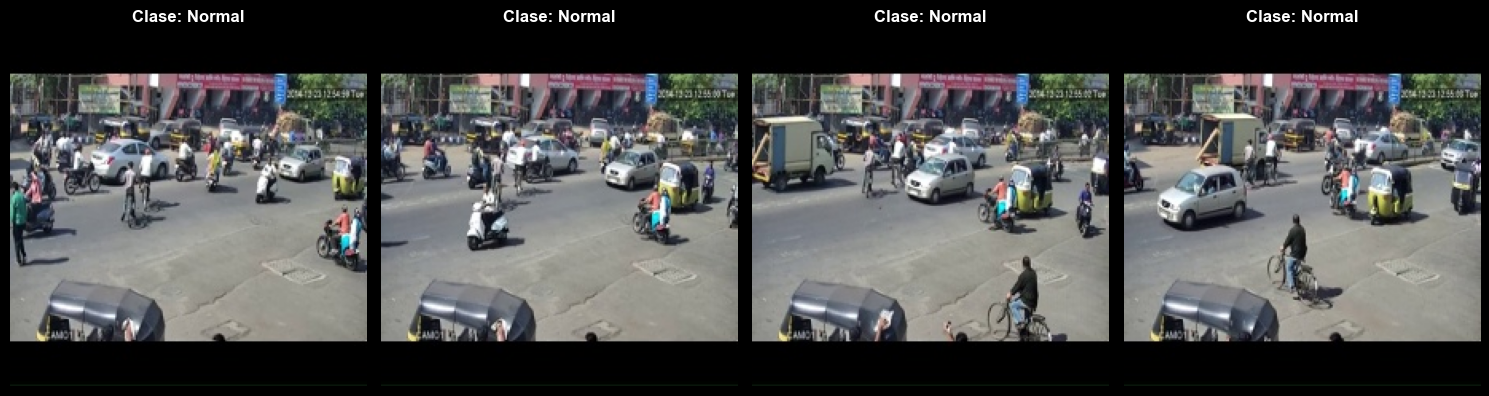

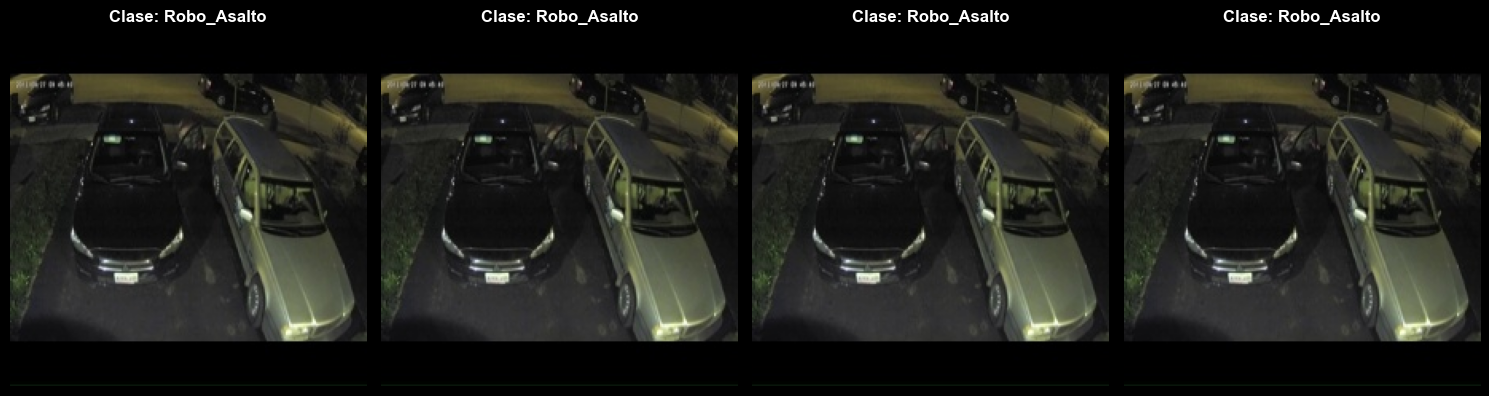

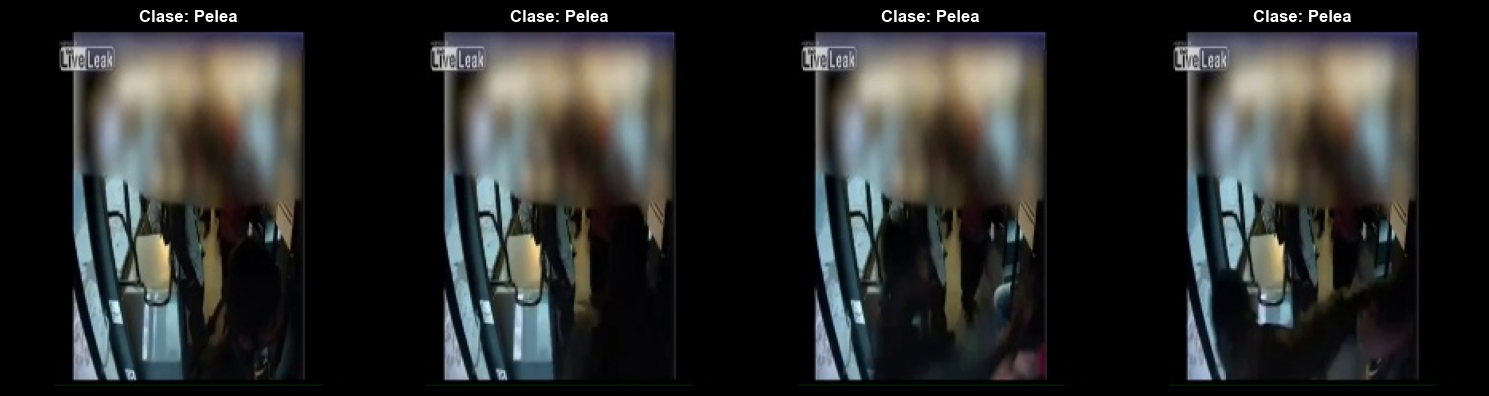

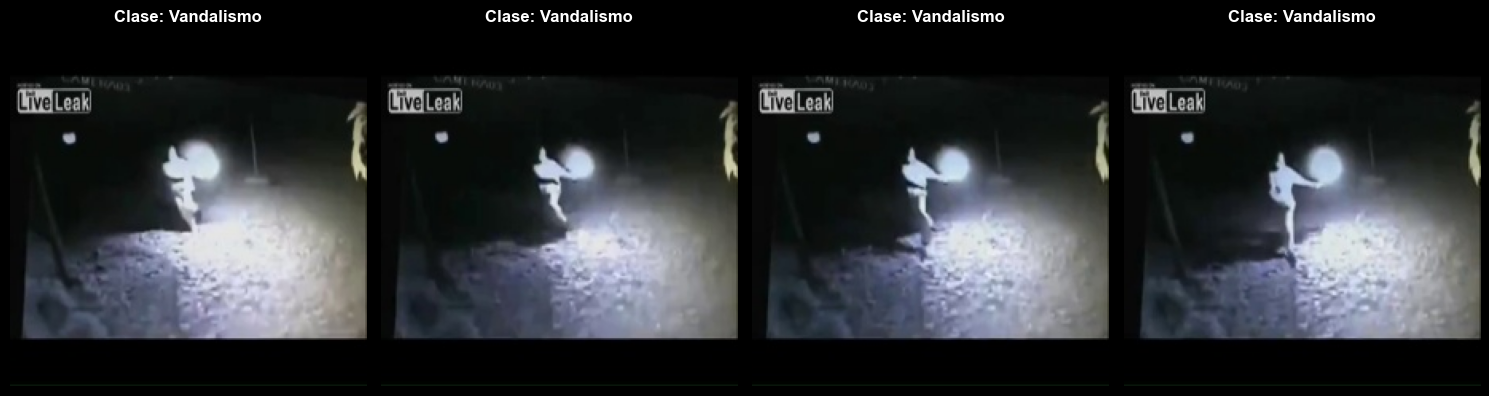

In [214]:
clases = ['Normal', 'Robo_Asalto', 'Pelea', 'Vandalismo']

def show_samples(base_path, class_name, n=4):
    imgs = list(Path(base_path, class_name).glob('*.jpg'))[:n]
    plt.figure(figsize=(15, 4))
    for i, img_path in enumerate(imgs):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f'Clase: {class_name}', fontweight='bold')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

for cls in clases:
    show_samples(train_path, cls)

**¿Cuántas imágenes tenemos en la carpeta de entrenamiento?**

In [215]:
for cls in clases:
    n = len(list(Path(train_path, cls).glob('*.jpg')))
    print(f'  {cls:<15}: {n:>5} frames')

  Normal         :   144 frames
  Robo_Asalto    :    48 frames
  Pelea          :   192 frames
  Vandalismo     :   288 frames


## 3.2 Análisis de distribución de clases

In [216]:
data = []
for cls in clases:
    count = len(list(Path(train_path, cls).glob('*.jpg')))
    data.append({'Clase': cls, 'Cantidad': count})

df = pd.DataFrame(data)
print("Resumen del Dataset:")
print(df)

Resumen del Dataset:
         Clase  Cantidad
0       Normal       144
1  Robo_Asalto        48
2        Pelea       192
3   Vandalismo       288


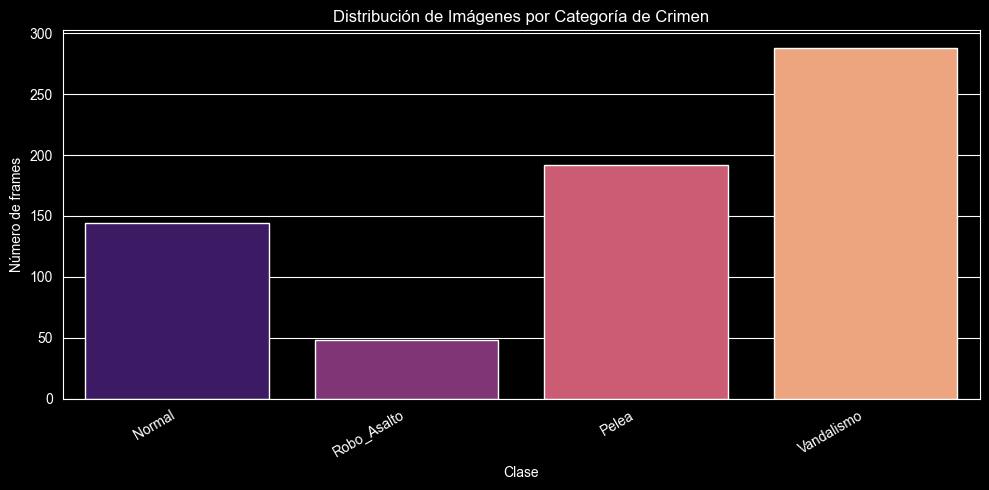

In [217]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Clase', y='Cantidad', palette='magma')
plt.title('Distribución de Imágenes por Categoría de Crimen')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Número de frames')
plt.tight_layout()
plt.show()

## 3.3 Calcular dimensiones promedio

In [218]:
#Debemos calcular unas dimensiones promedio que serán las que posteriormente pasemos a la CNN
dim1_all, dim2_all = [], []

for cls in clases:
    for fichero in list(Path(train_path, cls).glob('*.jpg'))[:30]:
        img = cv2.imread(str(fichero))
        if img is not None:
            d1, d2, _ = img.shape
            dim1_all.append(d1)
            dim2_all.append(d2)

print(f'Alto  promedio: {np.mean(dim1_all):.0f} px')
print(f'Ancho promedio: {np.mean(dim2_all):.0f} px')

Alto  promedio: 224 px
Ancho promedio: 224 px


In [219]:
image_shape = (224, 224, 3)

## 3.4 Manipulación de imágenes

Es buena idea manipular las imágenes con rotaciones, reescalados, desplazamientos,...
para hacer más robusto al modelo con más imágenes (artificiales) --> **ImageDataGenerator**

In [220]:
image_gen = ImageDataGenerator(
    rotation_range=20,         #rotación máxima de 20º (depende del caso de uso)
    width_shift_range=0.10,    #Desplazamiento en la anchura máximo del -10% --- +10%
    height_shift_range=0.10,   #Desplazamiento en la altura máximo del -10% --- +10%
    rescale=1/255,             #Reescalar la imagen para normalizarla entre 0-1
    shear_range=0.1,           #Distorsión de la imagen a partir de un eje - perspectiva (max 10%)
    zoom_range=0.1,            #Zoom in máximo 10%
    horizontal_flip=True,      #Permitir giro horizontal de la imagen (espejo)
    fill_mode='nearest'        #Rellenar píxeles vacíos con el valor más cercano
)

## 3.5 Generadores de train y test

In [221]:
batch_size = 32 #Definimos un batch_size en función de la RAM

train_image_gen = image_gen.flow_from_directory(
    train_path,
    target_size=image_shape[:2],   #image_shape = (224,224,3), target_size solo necesita alto x ancho
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'       #binary si clasificación binaria
)

Found 672 images belonging to 4 classes.


In [222]:
#En el conjunto de test no aplicamos shuffle para no 'barajar' las imágenes
test_image_gen = ImageDataGenerator(rescale=1/255).flow_from_directory(
    test_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 120 images belonging to 4 classes.


In [223]:
train_image_gen.class_indices

{'Normal': 0, 'Pelea': 1, 'Robo_Asalto': 2, 'Vandalismo': 3}

# 4.Creación del Modelo

In [224]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [225]:
#https://stats.stackexchange.com/questions/148139/rules-for-selecting-convolutional-neural-network-hyperparameters
model = Sequential()

# CAPA CONVOLUCIONAL
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=image_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# CAPA CONVOLUCIONAL (más capas convolucionales conforme mayor complejidad del dataset de imágenes, aumentar progresivamente número de filtros en potencia de 2)
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# CAPA CONVOLUCIONAL (más capas convolucionales conforme mayor complejidad del dataset de imágenes, aumentar progresivamente número de filtros en potencia de 2)
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# CAPA FLATTEN: Convierte el volumen 3D en un array de 1 dimensión antes de la capa densa
model.add(Flatten())

# CAPA DENSE (Indicar neuronas potencia de 2, variable para optimizar modelo)
model.add(Dense(256))
model.add(Activation('relu'))

# CAPA DROPOUT (ayuda a reducir overfitting desactivando aleatoriamente neuronas durante el entrenamiento)
model.add(Dropout(0.5))

# CAPA FINAL DE CLASIFICACIÓN (5 posibles clases = 5 neuronas, si fuera binario utilizar 'sigmoid' y 1 neurona)
model.add(Dense(4, activation='softmax'))


model.compile(loss='categorical_crossentropy', #binary_crossentropy si fuera binario
              optimizer='adam',
              metrics=['accuracy'])

In [226]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,700 (84.86 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

# 5.Entrenamiento del modelo

In [227]:
from tensorflow.keras.callbacks import EarlyStopping

In [228]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [229]:
import warnings
warnings.filterwarnings('ignore')

In [230]:
results = model.fit(
    train_image_gen,
    epochs=20,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 557ms/step - accuracy: 0.5506 - loss: 1.4840 - val_accuracy: 0.6000 - val_loss: 1.2975
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 518ms/step - accuracy: 0.7500 - loss: 0.6658 - val_accuracy: 0.5250 - val_loss: 1.1731
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 510ms/step - accuracy: 0.8170 - loss: 0.4713 - val_accuracy: 0.5083 - val_loss: 2.0482
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 529ms/step - accuracy: 0.8348 - loss: 0.3631 - val_accuracy: 0.4083 - val_loss: 2.4887
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 516ms/step - accuracy: 0.8750 - loss: 0.3213 - val_accuracy: 0.4000 - val_loss: 2.4895


In [231]:
from tensorflow.keras.models import load_model
path_modelos = '../src/models'
os.makedirs(path_modelos, exist_ok=True)

model.save(f'{path_modelos}/modelo_CNN_CCTV.h5')

In [232]:
losses = pd.DataFrame(model.history.history)

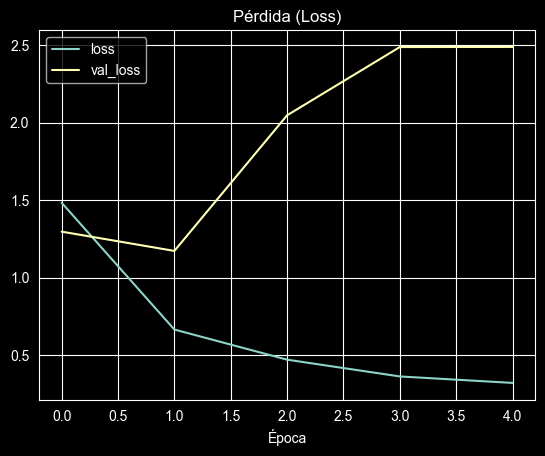

In [233]:
losses[['loss','val_loss']].plot()
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.show()

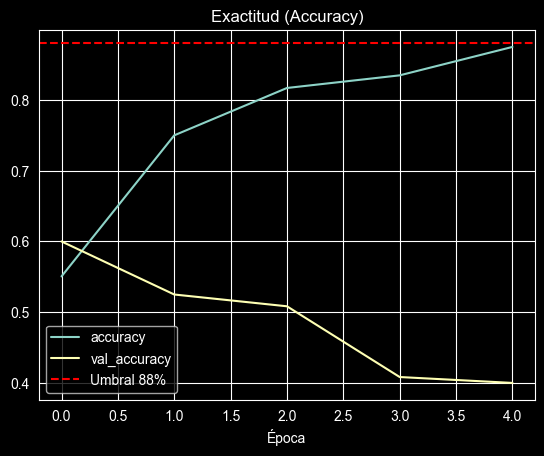

In [234]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Exactitud (Accuracy)')
plt.xlabel('Época')
plt.axhline(y=0.88, color='red', linestyle='--', label='Umbral 88%')
plt.legend()
plt.show()

# 6. Evaluación del modelo

## 6.1 Predicción sobre el conjunto de Test

In [235]:
model.metrics_names

['loss', 'compile_metrics']

In [236]:
model.evaluate(test_image_gen)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4000 - loss: 2.4895


[2.4894611835479736, 0.4000000059604645]

In [237]:
# https://datascience.stackexchange.com/questions/13894/how-to-get-predictions-with-predict-generator-on-streaming-test-data-in-keras
pred_probabilities = model.predict(test_image_gen)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [238]:
pred_probabilities

array([[9.9976403e-01, 3.3309445e-06, 1.0704716e-06, 2.3159265e-04],
       [9.9975675e-01, 3.1910208e-06, 1.0510154e-06, 2.3902542e-04],
       [9.9978119e-01, 2.2002619e-06, 9.9222393e-07, 2.1563310e-04],
       [9.9978703e-01, 2.0008413e-06, 9.3995214e-07, 2.1003261e-04],
       [9.9979049e-01, 1.9693396e-06, 8.2243878e-07, 2.0670371e-04],
       [9.9976403e-01, 1.9205472e-06, 1.1162748e-06, 2.3304205e-04],
       [9.9977976e-01, 2.0230029e-06, 9.0549736e-07, 2.1728507e-04],
       [9.9978667e-01, 2.1863368e-06, 8.0169093e-07, 2.1031113e-04],
       [9.9978203e-01, 2.1508943e-06, 8.1636318e-07, 2.1500986e-04],
       [9.9977463e-01, 2.5494833e-06, 8.7262856e-07, 2.2203485e-04],
       [9.9976712e-01, 2.1110839e-06, 1.1161047e-06, 2.2968744e-04],
       [9.9970978e-01, 2.5287022e-06, 1.5646151e-06, 2.8613125e-04],
       [9.9981898e-01, 2.0662033e-06, 7.2345910e-07, 1.7831878e-04],
       [9.9980658e-01, 2.1523772e-06, 8.2975436e-07, 1.9041313e-04],
       [9.9985242e-01, 2.9990490e-

In [239]:
test_image_gen.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [240]:
# predictions = model.predict_classes(test_image_gen)
#Usar si la sale predict_classes como deprecated:
predictions = np.argmax(model.predict(test_image_gen), axis=-1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [241]:
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [242]:
from sklearn.metrics import classification_report, confusion_matrix

In [243]:
nombres_clases = list(test_image_gen.class_indices.keys())
print(classification_report(test_image_gen.classes, predictions,
                             target_names=nombres_clases))

              precision    recall  f1-score   support

      Normal       0.33      1.00      0.50        24
       Pelea       0.29      0.21      0.24        24
 Robo_Asalto       0.00      0.00      0.00        24
  Vandalismo       0.83      0.40      0.54        48

    accuracy                           0.40       120
   macro avg       0.36      0.40      0.32       120
weighted avg       0.46      0.40      0.36       120



In [244]:
confusion_matrix(test_image_gen.classes, predictions)

array([[24,  0,  0,  0],
       [12,  5,  6,  1],
       [21,  0,  0,  3],
       [15, 12,  2, 19]])

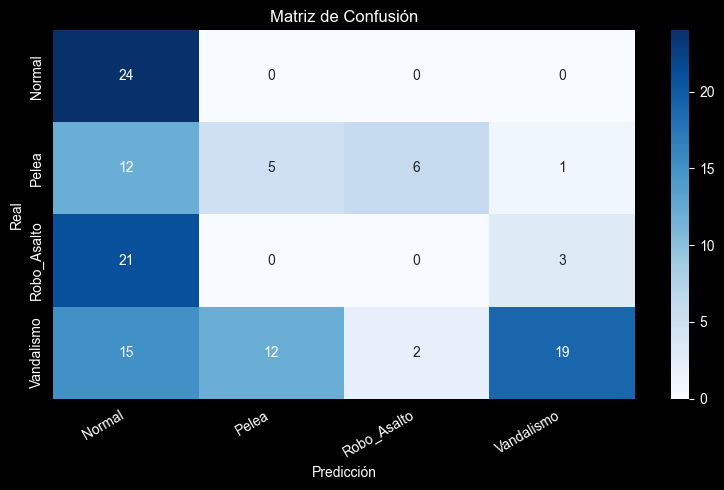

In [245]:
plt.figure(figsize=(8, 5))
sns.heatmap(confusion_matrix(test_image_gen.classes, predictions),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## 6.2 Gráfica de Precision, Recall y F1-score por clase

In [1]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    test_image_gen.classes, predictions,
    labels=list(range(len(nombres_clases))), zero_division=0
)

x     = np.arange(len(nombres_clases))
ancho = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Precision, Recall y F1-score por clase', fontsize=13, fontweight='bold')

bars1 = ax.bar(x - ancho, precision, ancho, label='Precision', color='#2980b9', edgecolor='white')
bars2 = ax.bar(x,          recall,    ancho, label='Recall',    color='#27ae60', edgecolor='white')
bars3 = ax.bar(x + ancho,  f1,        ancho, label='F1-score',  color='#e67e22', edgecolor='white')

ax.axhline(y=0.88, color='red', linestyle='--', linewidth=1.5, label='Umbral 88%')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(nombres_clases)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor')
ax.set_xlabel('Clase')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../src/reports/metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'test_image_gen' is not defined

## 6.3 Predicción para una nueva imagen

In [247]:
ruta_nueva_imagen = os.path.join(test_path, 'Pelea',
                     os.listdir(os.path.join(test_path, 'Pelea'))[0])

In [248]:
from tensorflow.keras.preprocessing import image

In [249]:
nueva_imagen = image.load_img(ruta_nueva_imagen, target_size=image_shape)

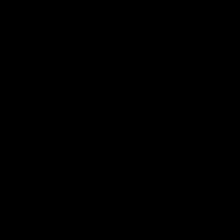

In [250]:
nueva_imagen

In [251]:
type(nueva_imagen)

PIL.JpegImagePlugin.JpegImageFile

In [252]:
nueva_imagen = image.img_to_array(nueva_imagen)

In [253]:
type(nueva_imagen)

numpy.ndarray

In [254]:
nueva_imagen.shape

(224, 224, 3)

In [255]:
nueva_imagen = np.expand_dims(nueva_imagen, axis=0)

In [256]:
nueva_imagen.shape

(1, 224, 224, 3)

In [257]:
model.predict(nueva_imagen) #Detecta la clase — la mayor probabilidad indica la predicción
#Usar si la sale predict_classes como deprecated: np.argmax(model.predict(nueva_imagen), axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


array([[0.00533813, 0.0095281 , 0.6358784 , 0.34925547]], dtype=float32)

In [258]:
test_image_gen.class_indices

{'Normal': 0, 'Pelea': 1, 'Robo_Asalto': 2, 'Vandalismo': 3}